In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from torch.utils.data import Dataset
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
from tqdm.auto import trange
import os
import random
from torch.utils.data import ConcatDataset
from LCNN_backend import LCNN
from moe_model import Classic_MOE
from sklearn.model_selection import train_test_split



d:\anaconda\envs\deepfake\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Dataset Directories**

In [2]:
# Number of file to pick in both training and development set
# num_files_to_pick = 10000    
# 
DATASET_MAP = {
    'asv2019': {
        'train': 'C:\\Users\\Zheng\\Desktop\\project\\team_lab_deepfake\\lfcc_tensors_train_set_with_delta\\lfcc_tensors_train_set_with_delta',
        'dev': 'C:\\Users\\Zheng\\Desktop\\project\\team_lab_deepfake\\lfcc_tensors_dev_set_with_delta\\lfcc_tensors_dev_set_with_delta',
        'eval': 'C:\\Users\\Zheng\\Desktop\\project\\team_lab_deepfake\\lfcc_tensors_eval_set_with_delta\\lfcc_tensors_eval_set_with_delta'
    },
    'add2022': {
        'train': 'C:\\Users\\Zheng\\Desktop\\project\\team_lab_deepfake\\add_lfcc_with_delta_train',
        'dev':   'C:\\Users\\Zheng\\Desktop\\project\\team_lab_deepfake\\add_lfcc_with_delta_dev',
        'eval': 'C:\\Users\\Zheng\\Desktop\\project\\team_lab_deepfake\\add_lfcc_with_delta_eval',
    },
    'itw': {
        'train': 'C:\\Users\\Zheng\\Desktop\\project\\team_lab_deepfake\\itw_lfcc_with_delta',
    }
}                                                  


**Process training data - Accumulate all datasets**

In [3]:
class MultiDatasetLoader(Dataset):
    def __init__(self, file_list_with_paths):
        """
        file_list_with_paths: List of tuples [(absolute_file_path), ...]
        """
        self.file_list = file_list_with_paths

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        # Load exactly ONE file into memory
        file_path = self.file_list[idx]
        feature, label = torch.load(file_path, weights_only=True)
        
        if not isinstance(label, torch.Tensor):
            label = torch.tensor(label)
            
        return feature, label

random_seed = 42
train_files_pool = []
dev_files_pool = []

for key in DATASET_MAP.keys():
    if key != 'itw':
        t_path = DATASET_MAP[key]['train']
        d_path = DATASET_MAP[key]['dev']
        train_files_pool.extend([os.path.join(t_path, f) for f in os.listdir(t_path) if f.endswith('.pt')])
        dev_files_pool.extend([os.path.join(d_path, f) for f in os.listdir(d_path) if f.endswith('.pt')])
    else:
        t_path = DATASET_MAP[key]['train']
        all_itw = [f for f in os.listdir(t_path) if f.endswith('.pt')]
        
        itw_train, itw_dev = train_test_split(all_itw, test_size=0.4, random_state=random_seed)
        itw_dev, itw_eval = train_test_split(itw_dev, test_size=0.5, random_state=random_seed)
        
        train_files_pool.extend([os.path.join(t_path, f) for f in itw_train])
        dev_files_pool.extend([os.path.join(t_path, f) for f in itw_dev])

print(f"Total compiled training files: {len(train_files_pool)}")
print(f"Total compiled validation files: {len(dev_files_pool)}")

train_dataset = MultiDatasetLoader(train_files_pool)
dev_dataset = MultiDatasetLoader(dev_files_pool)

dataLoader = DataLoader(train_dataset, batch_size=64, shuffle=True, pin_memory=True)
dev_dataLoader = DataLoader(dev_dataset, batch_size=64, shuffle=False, pin_memory=True)

print("The combined datasets have been successfully initialized")

Total compiled training files: 71531
Total compiled validation files: 59524
The combined datasets have been successfully initialized


In [4]:
# === Collect all training labels ===
def collect_all_labels(dataloader):
    all_labels = []
    all_features = []
    for features, labels in dataloader:
        all_labels.append(labels)
        all_features.append(features)
    all_features = torch.cat(all_features, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    return all_features, all_labels

combined_train_features, combined_train_labels = collect_all_labels(dataLoader)

print("Example of the train features",combined_train_features[1], "train feature shape:", combined_train_features.shape)
print("Example of the train labels",combined_train_labels, "label shape:", combined_train_labels.shape)

# === Label Distributions ===
print("Training label distribution:", torch.bincount(combined_train_labels))




Example of the train features tensor([[-3.5457e+02, -3.5591e+02, -3.5447e+02,  ..., -3.5093e+02,
         -3.4581e+02, -3.4534e+02],
        [ 2.2577e+01,  2.0828e+01,  2.2823e+01,  ...,  2.7163e+01,
          3.3265e+01,  3.4109e+01],
        [ 2.1657e+01,  2.0191e+01,  2.2060e+01,  ...,  2.4787e+01,
          2.8122e+01,  2.9314e+01],
        ...,
        [ 9.5969e-02,  9.5969e-02,  9.5969e-02,  ...,  6.6012e-02,
          6.6012e-02,  6.6012e-02],
        [ 1.4663e-01,  1.4663e-01,  1.4663e-01,  ...,  4.7067e-02,
          4.7067e-02,  4.7067e-02],
        [ 1.8781e-01,  1.8781e-01,  1.8781e-01,  ...,  6.1900e-02,
          6.1900e-02,  6.1900e-02]]) train feature shape: torch.Size([71531, 120, 126])
Example of the train labels tensor([0, 0, 0,  ..., 1, 0, 1]) label shape: torch.Size([71531])
Training label distribution: tensor([54005, 17526])


**Set up moe model and hyperparameters**

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

asv_checkpoint_path = "C:\\Users\\Zheng\\Desktop\\project\\team_lab_deepfake\\teamlab-phonetics\\advanced_baseline_model\\lcnn_checkpoint.pth"
itw_checkpoint_path = "C:\\Users\\Zheng\\Desktop\\project\\team_lab_deepfake\\teamlab-phonetics\\advanced_baseline_model\\lcnn_itw_checkpoint.pth"
add_checkpoint_path = "C:\\Users\\Zheng\\Desktop\\project\\team_lab_deepfake\\teamlab-phonetics\\advanced_baseline_model\\lcnn_add_checkpoint.pth"

expert1 = LCNN()  
expert2 = LCNN()  
expert3 = LCNN()  
    
# Load the trained weights
asv_checkpoint = torch.load(asv_checkpoint_path, map_location=device, weights_only=False)
itw_checkpoint = torch.load(itw_checkpoint_path, map_location=device, weights_only=False)
add_checkpoint = torch.load(add_checkpoint_path, map_location=device, weights_only=False)

expert1.load_state_dict(asv_checkpoint['model_state_dict'])
expert2.load_state_dict(itw_checkpoint['model_state_dict'])
expert3.load_state_dict(add_checkpoint['model_state_dict'])

expert1.train()
expert2.train()
expert3.train()

moe_model = Classic_MOE(experts=[expert1, expert2, expert3], feature_shape=[120,126])
moe_model.to(device)
# moe_optimizer = torch.optim.AdamW(moe_model.parameters(), lr=1e-4, weight_decay=1e-3)  # Learning rate + weight decay
moe_optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, moe_model.parameters()), lr=1e-4, weight_decay=1e-5)
#scheduler = CosineAnnealingLR(moe_optimizer, T_max=100, eta_min=1e-5)
moe_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(moe_optimizer, T_max=100, eta_min=1e-5)

cuda


**Set up loss function**

In [6]:

# Proportion of samples of the training set
combined_counts = torch.bincount(combined_train_labels) # tensor with [SPOOF, BONAFIDE]
combined_proportions = combined_counts / len(combined_train_labels) * 100
combined_prop_spoof = float(combined_proportions[0])
combined_prop_bonafide = float(combined_proportions[1])
print("Proportion of the Training Set:\n",f"Spoof: {combined_prop_spoof:.2f}% | Bonafide: {combined_prop_bonafide:.2f}%")


combined_weight_for_class_0 = (len(combined_train_labels) / (torch.bincount(combined_train_labels)[0] * 2))
print("Weight of class 0 (spoof):",combined_weight_for_class_0)

combined_weight_for_class_1 = (len(combined_train_labels) / (torch.bincount(combined_train_labels)[1] * 2))
print("Weight of class 1 (bonafide):",combined_weight_for_class_1)

combined_weighted_loss_pos = torch.tensor(combined_weight_for_class_1)
print("Weight tensor to be passed to the Loss Function",combined_weighted_loss_pos)


Proportion of the Training Set:
 Spoof: 75.50% | Bonafide: 24.50%
Weight of class 0 (spoof): tensor(0.6623)
Weight of class 1 (bonafide): tensor(2.0407)
Weight tensor to be passed to the Loss Function tensor(2.0407)


C:\Users\Zheng\AppData\Local\Temp\ipykernel_3672\3654404944.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  combined_weighted_loss_pos = torch.tensor(combined_weight_for_class_1)


In [7]:
moe_criterion = nn.BCEWithLogitsLoss(pos_weight=combined_weighted_loss_pos)  
#moe_criterion = nn.CrossEntropyLoss()

In [8]:
import matplotlib.pyplot as plt

# Initialize lists to store metrics
losses_train = [] # Stores the average training loss for each epoch.
losses_val = [] # Stores the average validation loss for each epoch.
accuracies_train = [] # Stores the training accuracy for each epoch.
accuracies_val = [] # Stores the validation accuracy for each epoch.
eers_val = []


# Initialize variables for early stopping
best_eer = float('inf')  # Track the best validation loss
patience = 15  # Number of epochs to wait for improvement
counter = 0   # Counter for early stopping
best_threshold = 0.0



**Training Loop**

In [9]:
from sklearn.metrics import roc_curve, f1_score
from scipy.special import expit  # sigmoid function
import numpy as np
import torch.nn.functional as F


num_epochs = 150

def calculate_eer(labels, scores):
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fnr - fpr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    return eer * 100, thresholds[eer_idx]


# --- Training Loop ---
for epoch in range(num_epochs):
    moe_model.train()
    epoch_loss_train = 0.0
    correct_train, total_train = 0, 0

    for features, labels in dataLoader:
        features, labels = features.to(device), labels.to(device)
        
        outputs, _ = moe_model(features)
        loss = moe_criterion(outputs, labels.float().unsqueeze(1))

        moe_optimizer.zero_grad()
        loss.backward()
        moe_optimizer.step()

        epoch_loss_train += loss.item()
        predicted = (outputs > 0.0).long().squeeze(1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_loss_train = epoch_loss_train / len(dataLoader)
    accuracy_train = 100 * correct_train / total_train
    losses_train.append(avg_loss_train)
    accuracies_train.append(accuracy_train)
# --- Validation ---
    moe_model.eval()
    epoch_loss_val = 0.0
    correct_val, total_val = 0, 0
    all_scores, all_labels = [], []

    with torch.no_grad():
        for features, labels in dev_dataLoader:
            features, labels = features.to(device), labels.to(device)

            outputs, _ = moe_model(features)
            loss = moe_criterion(outputs, labels.float())

            epoch_loss_val += loss.item()
            predicted = (outputs > 0.0).long().squeeze(1)
            correct_val += (predicted == labels).sum().item()
            total_val += labels.size(0)
            
            probabilities = F.softmax(outputs, dim=1)
            all_scores.extend(probabilities[:, 1].cpu().numpy())  # Use probability of positive class
            all_labels.extend(labels.cpu().numpy())

    # Compute average validation loss and accuracy for the epoch
    avg_loss_val = epoch_loss_val / len(dev_dataLoader)
    accuracy_val = 100 * correct_val / total_val
    losses_val.append(avg_loss_val)
    accuracies_val.append(accuracy_val)

    # --- Calculate EER on validation set ---
    eer_val, threshold_val = calculate_eer(np.array(all_labels), np.array(all_scores))
    eers_val.append(eer_val)

    # Print metrics
    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {avg_loss_train:.4f}, Acc: {accuracy_train:.2f}% | "
          f"Val Loss: {avg_loss_val:.4f}, Acc: {accuracy_val:.2f}% | "
          f"Val EER: {eer_val:.2f}%"
          f"Val Threshold: {threshold_val:.2f}")

    # Learning rate scheduling
    moe_scheduler.step()

    # --- Early Stopping Based on Validation EER ---
    if eer_val < best_eer:
        best_eer = eer_val
        best_threshold = threshold_val  # Save the threshold for best EER
        torch.save(moe_model.state_dict(), 'moe_delta.pth')
        #torch.save(expert1.state_dict(), 'moe_epoch20_eval_expert1.pth')
        #torch.save(expert2.state_dict(), 'moe_epoch20_eval_expert2.pth')
        print(f"New best model saved! EER: {eer_val:.2f}%")
        # Save the threshold to a file
        with open('moe_delta.txt', 'w') as f:
            f.write(str(best_threshold))
        counter = 0
    else:
        counter += 1
        print(f"EER not improved. Patience counter: {counter}/{patience}")
        if counter >= patience and epoch >= 10:
            print("Early stopping triggered (EER did not improve).")
            break
print(f"Training completed. Best EER: {best_eer:.2f}% with threshold: {best_threshold:.4f}")

ValueError: Target size (torch.Size([64, 1])) must be the same as input size (torch.Size([64]))

In [ ]:
torch.save(expert1.state_dict(), 'moe_expert1.pth')
torch.save(expert2.state_dict(), 'moe_expert2.pth')

**Prepare Evaluation dataset**

In [ ]:
# Evaluation
eval_data_dir = 'D:\\Stuttgart\\(important) Third Semester\\Team lab\\lfcc_tensors_eval_set_with_delta\\lfcc_tensors_eval_set_with_delta'

# Set the number of files to pick and the random seed
#random_seed = 42

# List all .pt files in the directory
all_files = [f for f in os.listdir(eval_data_dir) if f.endswith('.pt')]

# Set the random seed for reproducibility
#random.seed(random_seed)

# Randomly select the specified number of files
# selected_files = random.sample(all_files, num_files_to_pick)

# Inspect a single .pt file before loading into classes
inspect_file = os.path.join(eval_data_dir, all_files[0])  # Select the first file from the random selection

# Inspect the data from the .pt file
inspect_data = torch.load(inspect_file)
print("Example of the .pt file",inspect_data[0])

# Initialize a list to store the features and labels
eval_features_list = []
eval_labels_list = []

# Load the features and labels for the selected .pt files
for file_name in all_files:
    file_path = os.path.join(eval_data_dir, file_name)
    eval_feature, eval_label = torch.load(file_path)
    eval_features_list.append(eval_feature)  # Append the tensors
    eval_labels_list.append(eval_label) # Append the labels

# Concatenate all the data into a single tensor
eval_features = torch.stack(eval_features_list)
print("Example of the features",eval_features[1])
eval_labels = torch.tensor(eval_labels_list)
print("Example of the labels",eval_labels)

# Debugging: Check the shapes of features and labels
print("Features shape:", eval_features.shape)
print("Labels shape:", eval_labels.shape)

# Create a TensorDataset and DataLoader
eval_dataset = TensorDataset(eval_features, eval_labels)
eval_dataLoader = DataLoader(eval_dataset, batch_size=64, shuffle=False)
print("The evaluation dataset has been successfully loaded into DataLoader.")

Example of the .pt file tensor([[-3.1719e+02, -1.8039e+02, -6.8076e+01,  ..., -4.5134e+01,
         -3.8520e+01, -1.7389e+01],
        [ 8.4354e+01,  1.6613e+02,  2.0741e+02,  ...,  2.5119e+02,
          2.3634e+02,  2.3194e+02],
        [ 4.2919e+01,  3.2076e+01,  1.4553e+01,  ..., -4.7070e+00,
         -1.9970e+00, -8.4831e-02],
        ...,
        [ 1.7571e-02,  1.7571e-02,  1.7571e-02,  ...,  2.3086e-01,
          2.3086e-01,  2.3086e-01],
        [-4.9345e-01, -4.9345e-01, -4.9345e-01,  ...,  2.9802e-01,
          2.9802e-01,  2.9802e-01],
        [-1.0044e-01, -1.0044e-01, -1.0044e-01,  ...,  5.3810e-02,
          5.3810e-02,  5.3810e-02]])
Example of the features tensor([[-3.3888e+02, -3.7314e+02, -2.9060e+02,  ..., -3.8714e+02,
         -3.9049e+02, -3.9146e+02],
        [ 3.6489e+01,  3.1510e+01,  9.5408e+01,  ...,  2.2135e+01,
          1.7525e+01,  1.6173e+01],
        [ 1.3734e+01,  1.6058e+01,  4.1746e+01,  ...,  2.1536e+01,
          1.7273e+01,  1.5978e+01],
        ...

In [ ]:
from torch.utils.data import Dataset, DataLoader
eval_data_dir = 'D:\\Stuttgart\\(important) Third Semester\\Team lab\\lfcc_tensors_eval_set_with_delta\\lfcc_tensors_eval_set_with_delta'

class LFCCEvalDataset(Dataset):
    def __init__(self, directory):
        self.file_paths = [os.path.join(directory, f) for f in os.listdir(directory) if f.endswith(".pt")]

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        feature, label = torch.load(self.file_paths[idx])
        return feature, label
eval_dataset = LFCCEvalDataset(eval_data_dir)
eval_dataLoader = DataLoader(eval_dataset, batch_size=32, shuffle=False)
print(f"Number of evaluation samples: {len(eval_dataset)}")
for features, labels in eval_dataLoader:
    print("Batch features shape:", features.shape)
    print("Batch labels shape:", labels.shape)
    break  # Remove this break to iterate through all batches

Number of evaluation samples: 71237
Batch features shape: torch.Size([32, 120, 126])
Batch labels shape: torch.Size([32])



Evaluation Set:
Loss: 2.3568 | Accuracy: 70.01%
EER: 14.15% | Threshold used: 0.9998
F1 Score: 0.5560
Precision: 0.4111
Recall: 0.8585
Predictions: [1]: 15357 | [0]: 55880


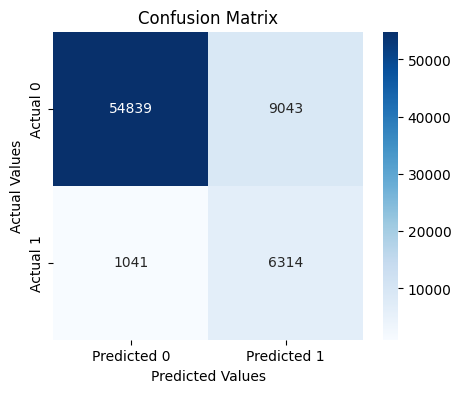

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import roc_curve, f1_score
from scipy.special import expit  # sigmoid function
import numpy as np
import torch.nn.functional as F


num_epochs = 150

def calculate_eer(labels, scores):
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fnr - fpr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    return eer * 100, thresholds[eer_idx]

#trained_moe_experted1 = "D:\\Stuttgart\\(important) Third Semester\\Team lab\\moe_epoch10_V2expert1.pth"
#trained_moe_experted2 = "D:\\Stuttgart\\(important) Third Semester\\Team lab\\moe_epoch10_V2expert2.pth"
#expert1 = LCNN(input_size=[40,126])  # Assuming input_size is the shape of the features
#expert2 = LCNN(input_size=[40,126])
#expert1.load_state_dict(torch.load(trained_moe_experted1, map_location=device))
#expert2.load_state_dict(torch.load(trained_moe_experted2, map_location=device))
moe_model_path = "D:\\Stuttgart\\(important) Third Semester\\Team lab\\moe_delta_10_v2.pth"
moe= Enhanced_MOE([expert1.to(device), expert2.to(device)]).to(device)
moe.load_state_dict(torch.load(moe_model_path))

def evaluate_on_eval_set(model, eval_dataLoader):
    model.eval()
    all_scores = []
    all_labels = []
    total = 0
    correct = 0
    total_loss = 0.0

    with torch.no_grad():
        for features, labels in eval_dataLoader:
            features, labels = features.to(device), labels.to(device)
            outputs, _ = model(features)
            loss = moe_criterion(outputs, labels.long())

            total_loss += loss.item()
            predicted = outputs.argmax(dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            probabilities = F.softmax(outputs, dim=1)
            all_scores.extend(probabilities[:, 1].cpu().numpy())  # Use probability of positive class
            all_labels.extend(labels.cpu().numpy())

    # Convert to NumPy arrays
    all_labels = np.array(all_labels)
    all_scores = np.array(all_scores)
    
    # Metrics
    avg_loss = total_loss / len(eval_dataLoader)
    accuracy = 100 * correct / total
    eer, threshold = calculate_eer(all_labels, all_scores)
    preds = (all_scores >= threshold).astype(int)
    
    # Calculate precision and recall
    precision = precision_score(all_labels, preds)
    recall = recall_score(all_labels, preds)
    f1 = f1_score(all_labels, preds)

    # Print results with precision and recall
    print(f"\nEvaluation Set:")
    print(f"Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")
    print(f"EER: {eer:.2f}% | Threshold used: {threshold:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"Predictions: [1]: {np.count_nonzero(preds == 1)} | [0]: {np.count_nonzero(preds == 0)}")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.xlabel('Predicted Values')
    plt.ylabel('Actual Values')
    plt.title('Confusion Matrix')
    plt.show()

evaluate_on_eval_set(moe, eval_dataLoader)